<a href="https://colab.research.google.com/github/tyomapr/HR-Job-Market-Analysis-1-January---1-April-2026-/blob/main/HR_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR Skill Demand Analysis

In [1]:
import pandas as pd

hr_dataset = pd.read_excel('HR_analysis_full_updated.xlsx')

This notebook begins by loading the HR dataset from an Excel file. This dataset contains information about job requirements, which will be analyzed to extract skill demands.

## Consolidated Visualizations of HR Skill Demands

This section consolidates all the key visualizations generated during the HR skill demand analysis. These plots illustrate the top skills across different HR branches, overall skill demands, and specific breakdowns for IT/AI/Tech skills and HR systems/tools.


Generating Top 10 Skills for Each HR Branch...

--- Top 10 Skills for HR Branch: HR Business Partner & Leadership ---


,Skill,Mentions
1,knowledge of employment law,14
2,employee relations knowledge,13
3,finnish and english fluency,9
4,recruitment experience,9
5,english fluency,9
6,5+ years of relevant experience,8
7,stakeholder management,8
8,collaboration skills,7
9,knowledge of collective agreements,6
10,hr process knowledge,6


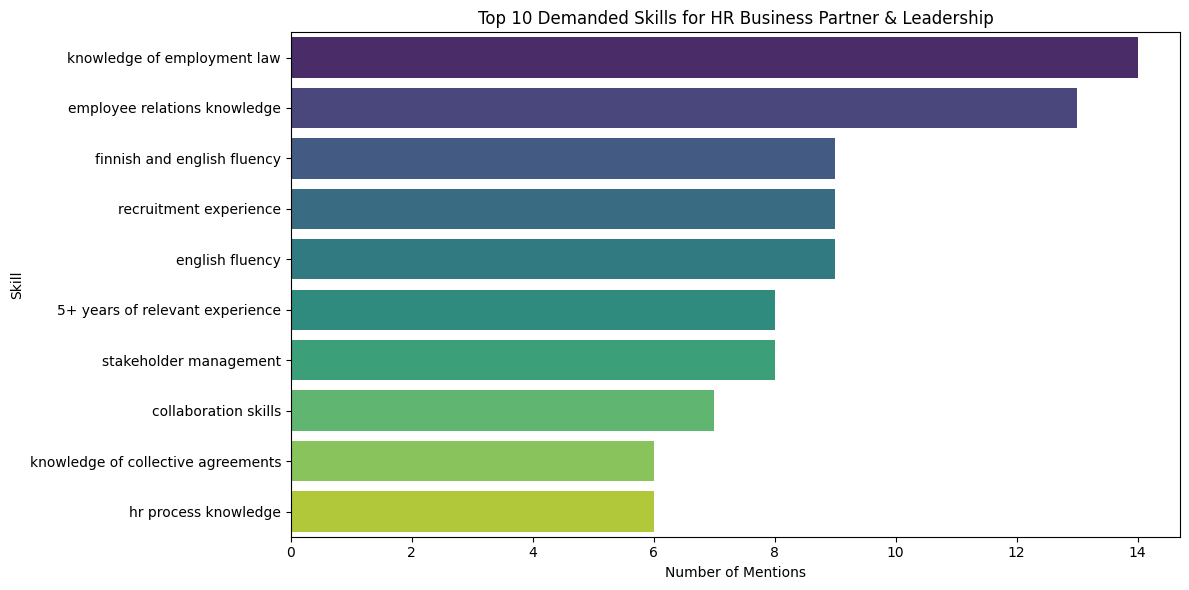


--- Top 10 Skills for HR Branch: Talent Acquisition ---


,Skill,Mentions
1,recruitment experience,27
2,finnish fluency,15
3,finnish and english fluency,9
4,strong communication skills,8
5,process development,7
6,stakeholder management,7
7,hr administration experience,7
8,data management,6
9,english fluency,6
10,customer service orientation,6


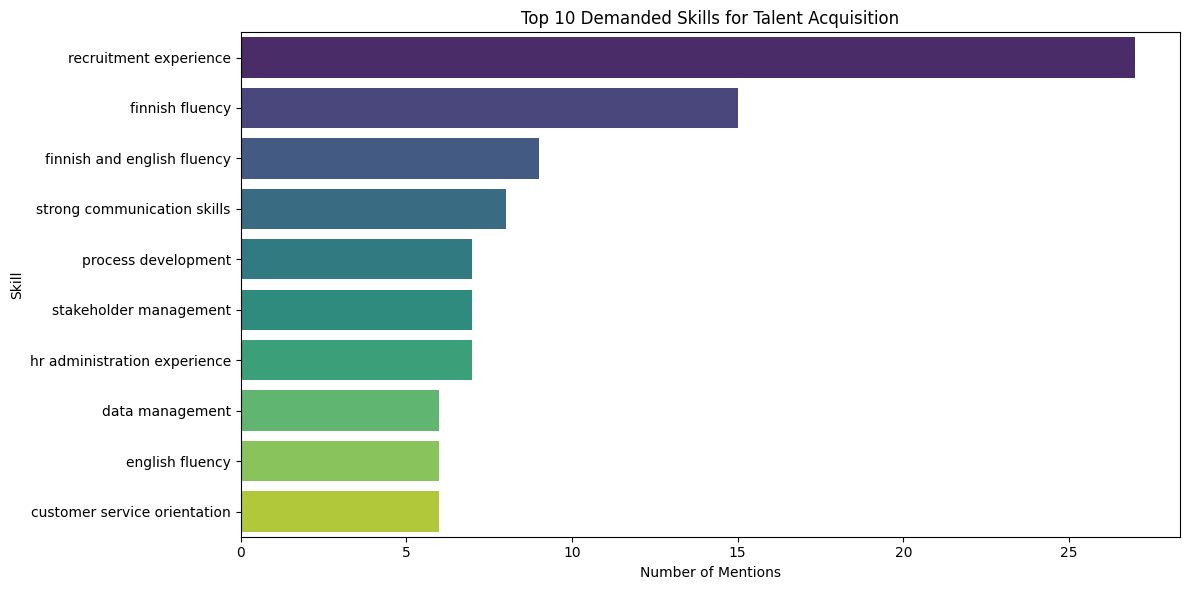


--- Top 10 Skills for HR Branch: Compensation & Payroll ---


,Skill,Mentions
1,payroll experience,18
2,finnish and english fluency,13
3,hr administration experience,7
4,knowledge of collective agreements,6
5,recruitment experience,6
6,employee relations knowledge,6
7,knowledge of employment law,6
8,finnish fluency,4
9,several years of relevant experience,3
10,strong communication skills,3


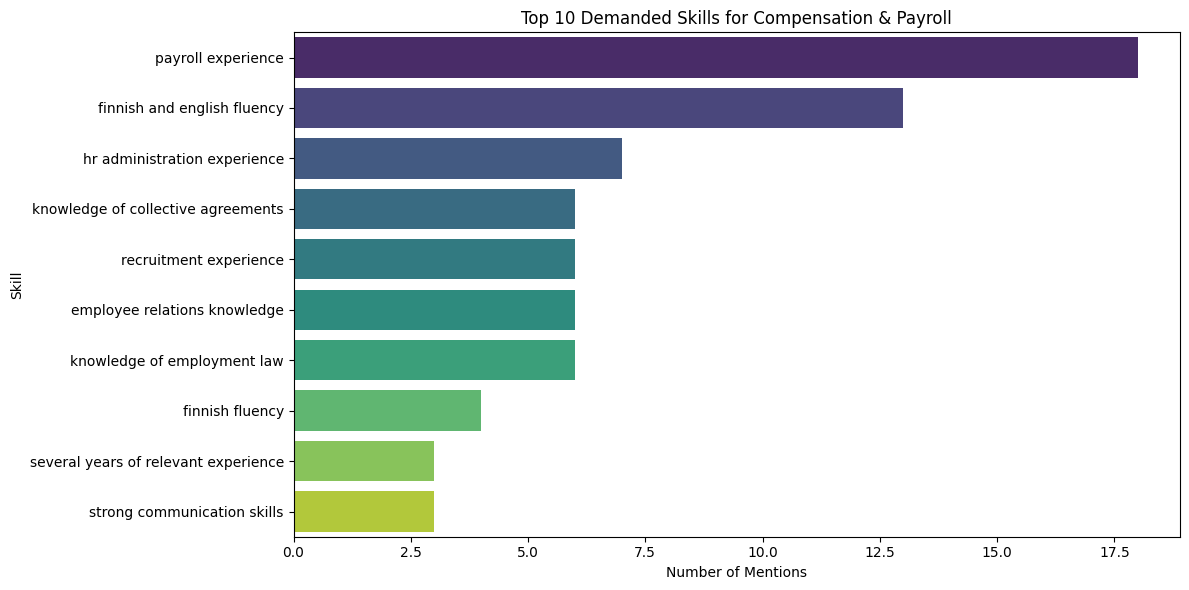


--- Top 10 Skills for HR Branch: HR Operations & Administration ---


,Skill,Mentions
1,attention to detail,7
2,finnish fluency,6
3,finnish and english fluency,5
4,data management,5
5,employee relations knowledge,4
6,english fluency,4
7,hr process knowledge,4
8,stakeholder management,4
9,strong communication skills,4
10,knowledge of employment law,3


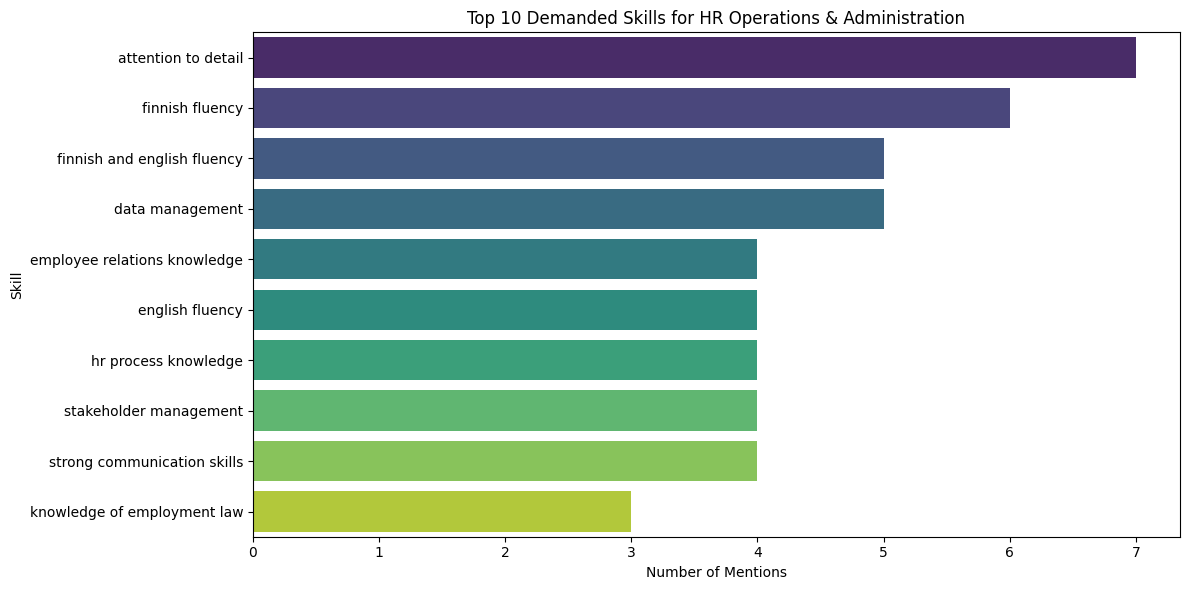


--- Top 10 Skills for HR Branch: HR Generalist ---


,Skill,Mentions
1,process development,4
2,training or facilitation skills,4
3,collaboration skills,3
4,finnish fluency,3
5,strong communication skills,3
6,attention to detail,2
7,recruitment support,2
8,several years of relevant experience,1
9,finnish and english fluency,1
10,knowledge of employment law,1


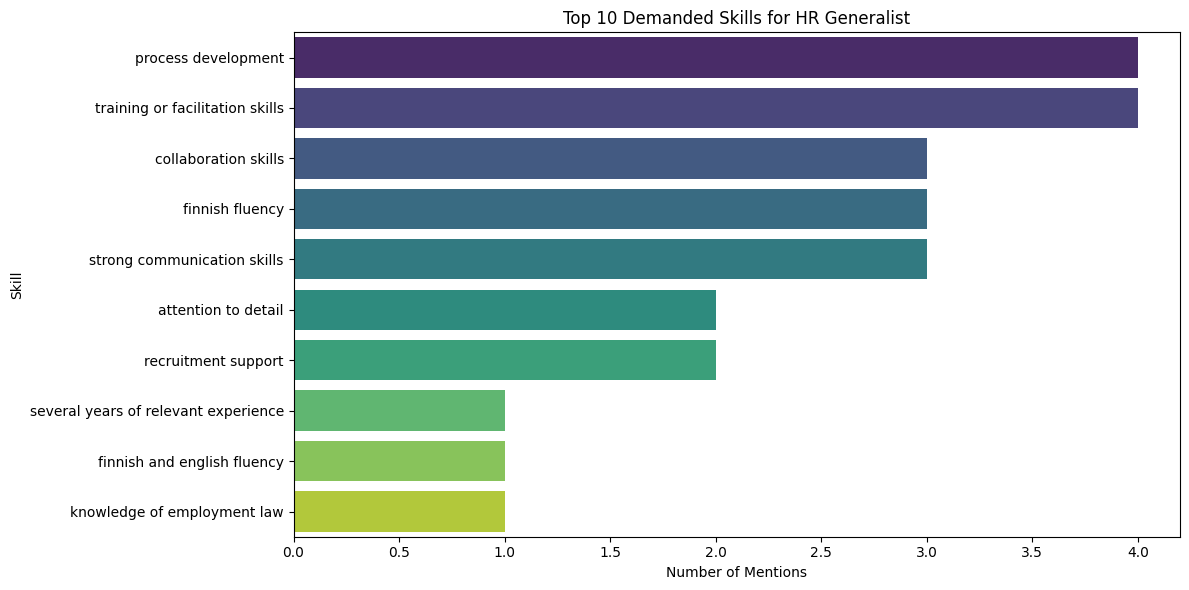


--- Top 10 Skills for HR Branch: Learning & Development ---


,Skill,Mentions
1,stakeholder management,6
2,english fluency,5
3,excel,5
4,finnish and english fluency,5
5,finnish fluency,5
6,knowledge of collective agreements,4
7,customer service orientation,4
8,hr process knowledge,4
9,recruitment experience,4
10,process development,4


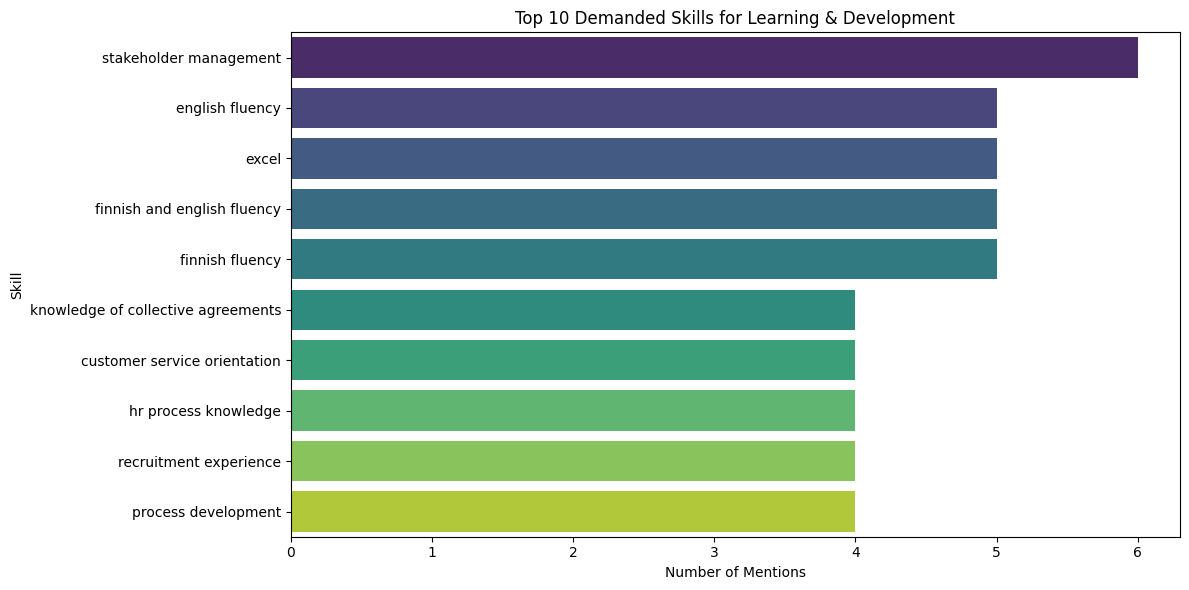


--- Top 10 Skills for HR Branch: Employee Experience & Culture ---


,Skill,Mentions
1,finnish and english fluency,2
2,recruitment experience,2
3,hr process knowledge,2
4,analytical skills,2
5,project management,2
6,stakeholder management,2
7,english fluency,2
8,data management,1
9,several years of relevant experience,1
10,finnish fluency,1


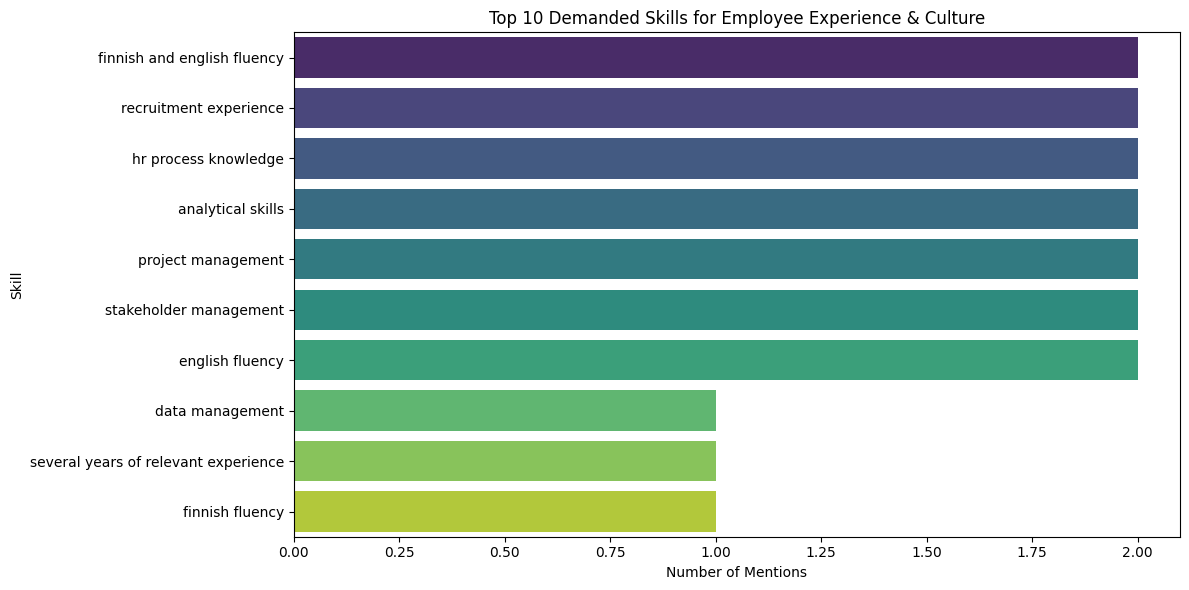


--- Top 10 Skills for HR Branch: Other / Non-HR ---


,Skill,Mentions
1,collaboration skills,2
2,process development,2
3,7+ years of relevant experience,1
4,english fluency,1
5,strong communication skills,1
6,analytical skills,1
7,data management,1
8,finnish and english fluency,1
9,project management,1
10,organizational skills,1


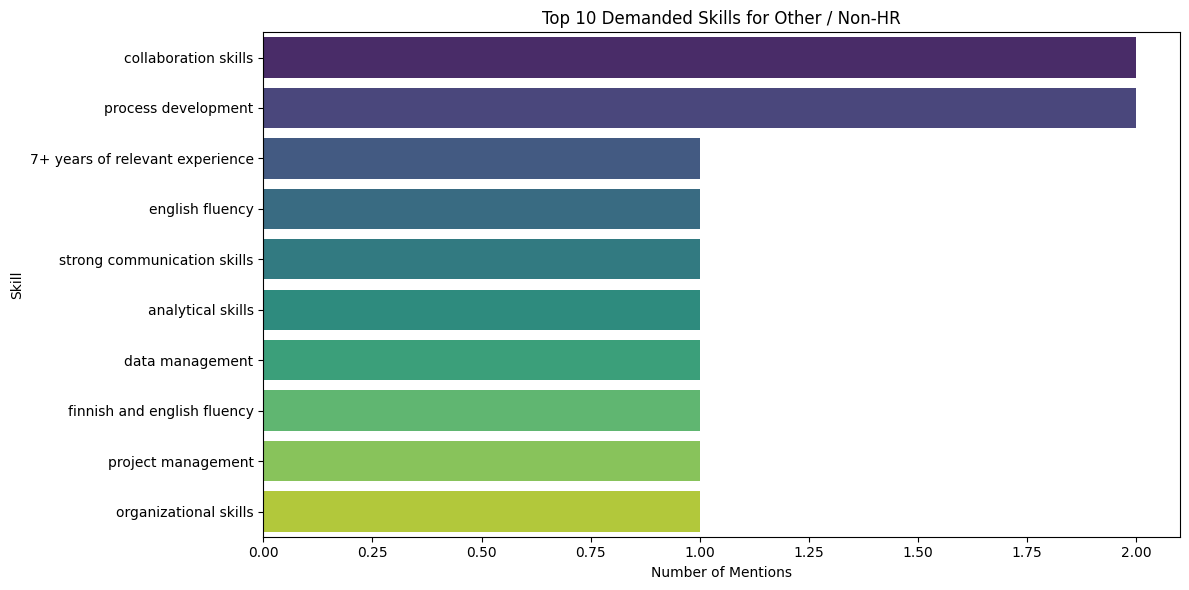


Generating Overall Top 10 Demanded Skills...

--- Overall Top 10 Demanded Skills ---


,Skill,Mentions
1,recruitment experience,48
2,finnish and english fluency,45
3,finnish fluency,40
4,employee relations knowledge,30
5,stakeholder management,30
6,english fluency,29
7,strong communication skills,28
8,knowledge of employment law,27
9,payroll experience,25
10,process development,22


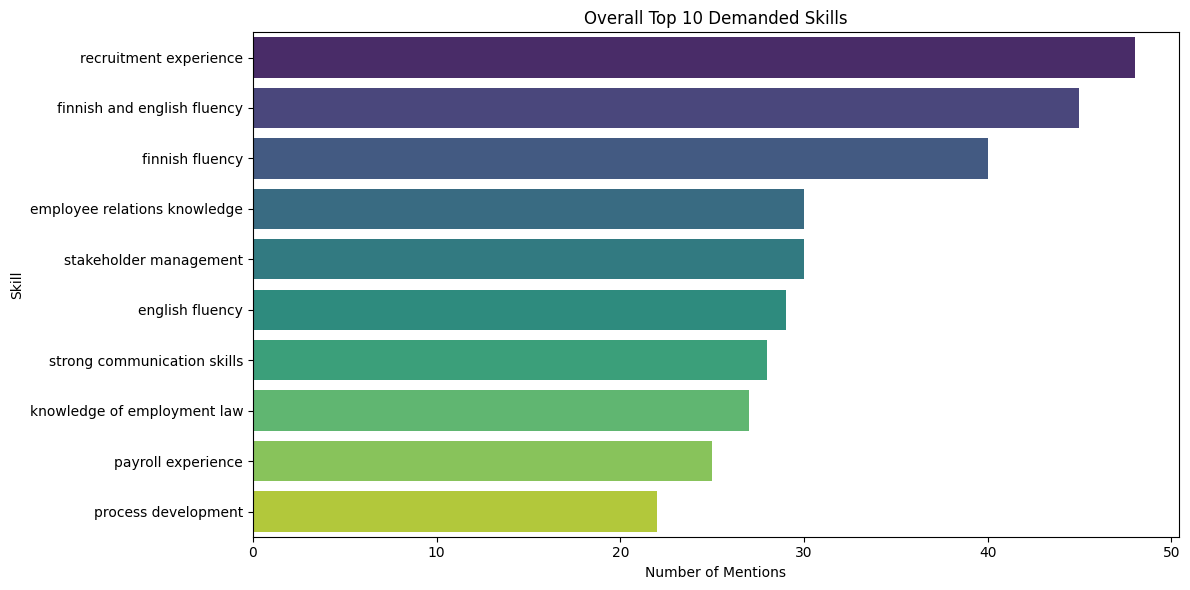


Generating Top 5-10 IT/AI/Tech Skills...

--- Top 5-10 IT/AI/Tech Skills ---


,Skill,Mentions
1,general it skills,3
2,hr technology knowledge,1
3,software skills,1
4,good it basics,1
5,prior it recruitment experience,1


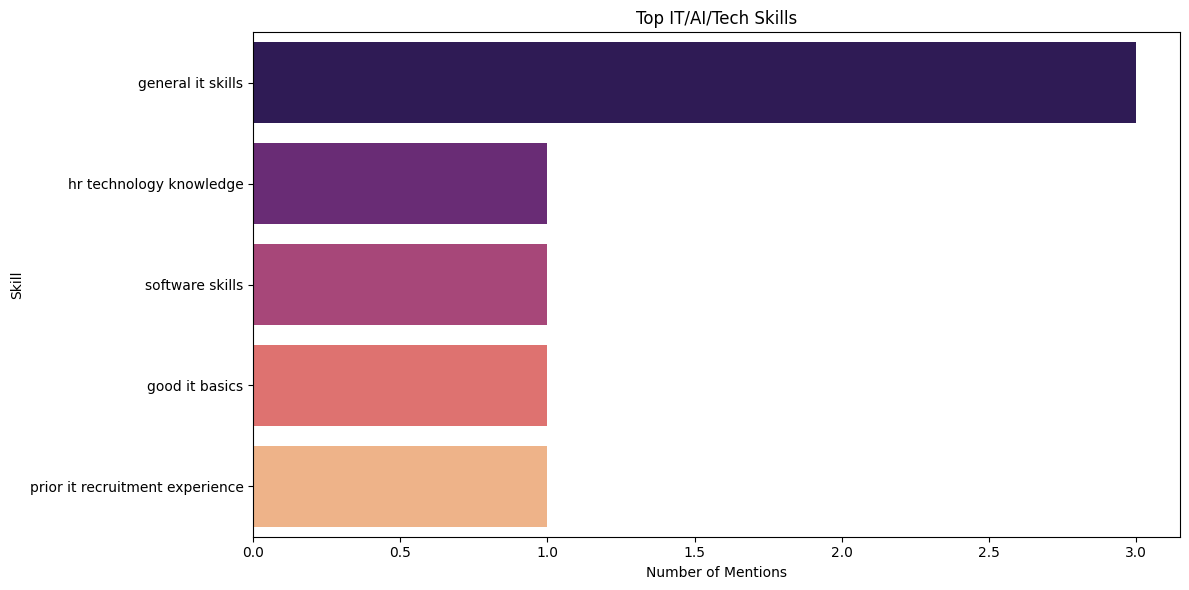


Generating Top HR Systems, Programs, or Tools...

--- Top HR Systems/Tools mentions ---


,Skill,Mentions
1,excel,14
2,workday,5
3,microsoft office skills,3
4,hr systems experience,2
5,lms experience,1
6,oracle hcm expertise,1


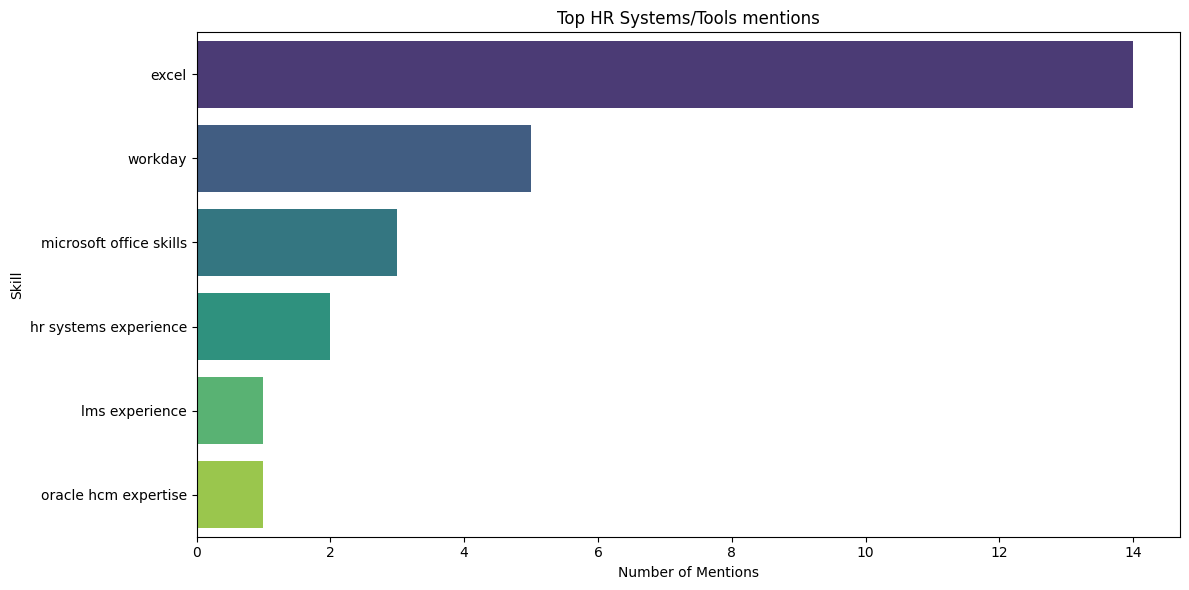


Generating Top 10 Advantages...

--- Overall Top 10 Advantages ---


,Advantage,Mentions
1,international work experience,7
2,payroll experience,5
3,international experience,5
4,knowledge of collective agreements,3
5,process development,3
6,organizational skills,3
7,recruitment experience,3
8,english language skills,2
9,hcm systems,2
10,retail industry experience,2


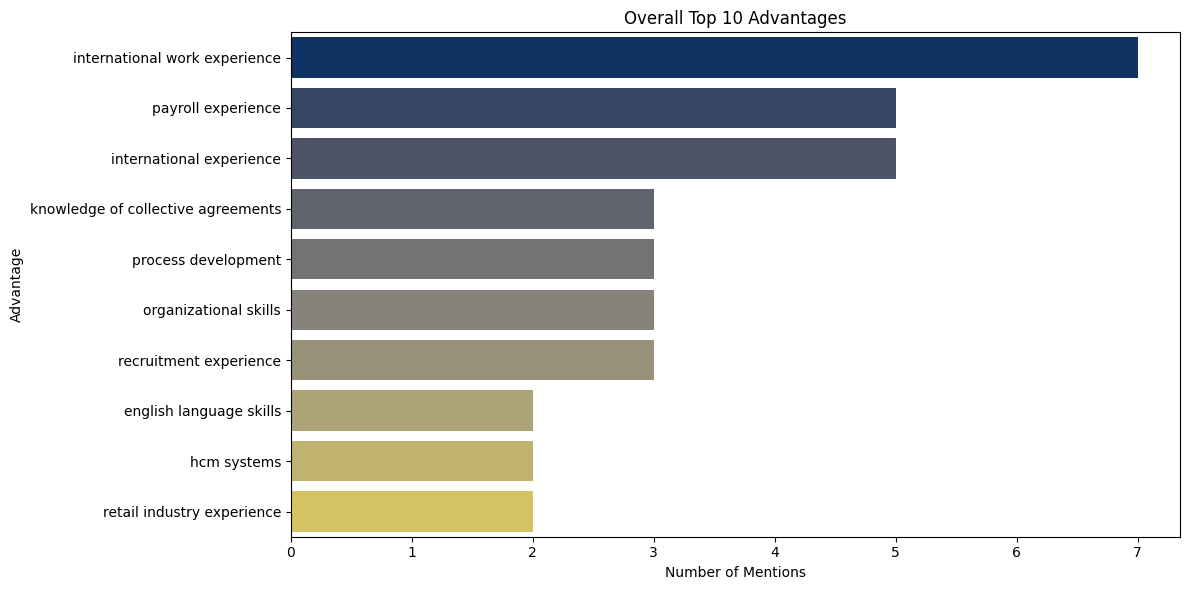

In [21]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Re-define constants and re-create data structures if they might not be globally available
# (Though in a continuous Colab session, they should be, but good practice for consolidation)
SKILLS_COLUMN = 'Requirements'
HR_BRANCH_COLUMN = 'HR branch'
ADVANTAGE_COLUMN = 'Advantage'

# Ensure hr_dataset is loaded if not already
# This check is mostly for standalone execution, in Colab the variable persists.
# if 'hr_dataset' not in globals():
#     hr_dataset = pd.read_excel('HR_analysis_full_updated.xlsx')

# --- 1. Top 10 Skills for Each HR Branch ---
print('Generating Top 10 Skills for Each HR Branch...')
if SKILLS_COLUMN in hr_dataset.columns and HR_BRANCH_COLUMN in hr_dataset.columns:
    unique_hr_branches = hr_dataset[HR_BRANCH_COLUMN].unique()
    for branch in unique_hr_branches:
        if pd.isna(branch):
            branch_name = "Unknown/Not Specified"
            branch_skills_df = hr_dataset[hr_dataset[HR_BRANCH_COLUMN].isna()]
        else:
            branch_name = str(branch)
            branch_skills_df = hr_dataset[hr_dataset[HR_BRANCH_COLUMN] == branch]

        all_skills = []
        for skills_str in branch_skills_df[SKILLS_COLUMN].dropna():
            skills = [s.strip().lower() for s in skills_str.split(';') if s.strip()]
            all_skills.extend(skills)

        skill_counts = Counter(all_skills)

        if skill_counts:
            top_skills = pd.DataFrame(skill_counts.most_common(10), columns=['Skill', 'Mentions'])
            top_skills.index = np.arange(1, len(top_skills) + 1) # Adjust index to start from 1
            print(f"\n--- Top 10 Skills for HR Branch: {branch_name} ---")
            display(top_skills)
            plt.figure(figsize=(12, 6))
            sns.barplot(x='Mentions', y='Skill', hue='Skill', data=top_skills, palette='viridis', legend=False)
            plt.title(f'Top 10 Demanded Skills for {branch_name}')
            plt.xlabel('Number of Mentions')
            plt.ylabel('Skill')
            plt.tight_layout()
            plt.show()
        else:
            print(f"No skills found for HR Branch: {branch_name}.")
else:
    print(f"Error: Missing expected columns '{SKILLS_COLUMN}' or '{HR_BRANCH_COLUMN}' for branch analysis.")


# --- 2. Overall Top 10 Demanded Skills ---
print('\nGenerating Overall Top 10 Demanded Skills...')
if SKILLS_COLUMN in hr_dataset.columns:
    all_skills_overall = []
    for skills_str in hr_dataset[SKILLS_COLUMN].dropna():
        skills = [s.strip().lower() for s in skills_str.split(';') if s.strip()]
        all_skills_overall.extend(skills)

    skill_counts_overall = Counter(all_skills_overall)

    if skill_counts_overall:
        top_10_overall_skills = pd.DataFrame(skill_counts_overall.most_common(10), columns=['Skill', 'Mentions'])
        top_10_overall_skills.index = np.arange(1, len(top_10_overall_skills) + 1) # Adjust index to start from 1
        print("\n--- Overall Top 10 Demanded Skills ---")
        display(top_10_overall_skills)
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Mentions', y='Skill', hue='Skill', data=top_10_overall_skills, palette='viridis', legend=False)
        plt.title('Overall Top 10 Demanded Skills')
        plt.xlabel('Number of Mentions')
        plt.ylabel('Skill')
        plt.tight_layout()
        plt.show()
    else:
        print("No skills found in the dataset for overall analysis.")
else:
    print(f"Error: Missing expected column '{SKILLS_COLUMN}' for overall analysis.")


# --- 3. Top 5-10 IT/AI/Tech Skills ---
print('\nGenerating Top 5-10 IT/AI/Tech Skills...')
tech_keywords = ['it', 'ai', 'artificial intelligence', 'machine learning', 'data science', 'analytics', 'software', 'cloud', 'aws', 'azure', 'google cloud', 'cybersecurity', 'programming', 'sql', 'python', 'r', 'java', 'c++', 'javascript', 'html', 'css', 'api', 'erp', 'crm', 'saas', 'ux', 'ui', 'agile', 'scrum', 'devops', 'automation', 'digital', 'technology', 'tech', 'system', 'platform']

it_ai_tech_skills = Counter()
if 'skill_counts_overall' in locals() or 'skill_counts_overall' in globals(): # Ensure skill_counts_overall exists
    for skill, count in skill_counts_overall.items():
        matched = False
        for keyword in tech_keywords:
            if re.search(r'\b' + re.escape(keyword) + r'\b', skill):
                matched = True
                break
        if matched:
            it_ai_tech_skills[skill] = count

    if it_ai_tech_skills:
        top_it_ai_tech_skills = pd.DataFrame(it_ai_tech_skills.most_common(10), columns=['Skill', 'Mentions'])
        if len(top_it_ai_tech_skills) > 5:
            top_it_ai_tech_skills = top_it_ai_tech_skills.head(10)
        else:
            top_it_ai_tech_skills = top_it_ai_tech_skills.head(5)
        top_it_ai_tech_skills.index = np.arange(1, len(top_it_ai_tech_skills) + 1) # Adjust index to start from 1
        print("\n--- Top 5-10 IT/AI/Tech Skills ---")
        display(top_it_ai_tech_skills)
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Mentions', y='Skill', hue='Skill', data=top_it_ai_tech_skills, palette='magma', legend=False)
        plt.title('Top IT/AI/Tech Skills')
        plt.xlabel('Number of Mentions')
        plt.ylabel('Skill')
        plt.tight_layout()
        plt.show()
    else:
        print("No IT/AI/Tech skills found in the dataset.")
else:
    print("Error: 'skill_counts_overall' not available for IT/AI/Tech skill analysis.")


# --- 4. Top HR Systems, Programs, or Tools ---
print('\nGenerating Top HR Systems, Programs, or Tools...')
specific_hr_keywords = ['sap hr', 'workday', 'successfactors', 'oracle hcm', 'adp', 'greenhouse', 'breezy hr', 'excel', 'power bi', 'word', 'office 365', 'microsoft office', 'google workspace', 'jira', 'confluence', 'slack', 'teams']
unspecific_hr_keywords = ['hr system', 'hrms', 'applicant tracking system', 'ats', 'payroll system', 'lms', 'learning management system', 'hr systems experience', 'hr systems expertise', 'hris', 'hr tools']

# Combine both specific and unspecific keywords
all_hr_systems_keywords = specific_hr_keywords + unspecific_hr_keywords

hr_systems_tools_skills = Counter()

if 'skill_counts_overall' in locals() or 'skill_counts_overall' in globals(): # Ensure skill_counts_overall exists
    for skill, count in skill_counts_overall.items():
        for keyword in all_hr_systems_keywords:
            if re.search(r'\b' + re.escape(keyword) + r'\b', skill):
                hr_systems_tools_skills[skill] = count
                break

    # Apply consolidation rules here
    consolidated_hr_systems_tools_skills = Counter()
    for skill, count in hr_systems_tools_skills.items():
        if "hr systems expertise" in skill:
            consolidated_hr_systems_tools_skills["hr systems experience"] += count
        elif "advanced excel" in skill:
            consolidated_hr_systems_tools_skills["excel"] += count
        elif "strong excel and powerpoint" in skill or "hris and microsoft office skills" in skill:
            consolidated_hr_systems_tools_skills["microsoft office skills"] += count
        else:
            consolidated_hr_systems_tools_skills[skill] += count

    if consolidated_hr_systems_tools_skills:
        top_hr_systems_tools = pd.DataFrame(consolidated_hr_systems_tools_skills.most_common(10), columns=['Skill', 'Mentions'])
        if len(top_hr_systems_tools) > 5:
            top_hr_systems_tools = top_hr_systems_tools.head(10)
        else:
            top_hr_systems_tools = top_hr_systems_tools.head(5)
        top_hr_systems_tools.index = np.arange(1, len(top_hr_systems_tools) + 1) # Adjust index to start from 1
        print("\n--- Top HR Systems/Tools mentions ---")
        display(top_hr_systems_tools)
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Mentions', y='Skill', hue='Skill', data=top_hr_systems_tools, palette='viridis', legend=False)
        plt.title('Top HR Systems/Tools mentions')
        plt.xlabel('Number of Mentions')
        plt.ylabel('Skill')
        plt.tight_layout()
        plt.show()
    else:
        print("No HR systems/tools skills found in the dataset.")
else:
    print("Error: 'skill_counts_overall' not available for HR systems/tools analysis.")


# --- 5. Top 10 Advantages ---
print('\nGenerating Top 10 Advantages...')
if ADVANTAGE_COLUMN in hr_dataset.columns:
    all_advantages = []
    for advantage_str in hr_dataset[ADVANTAGE_COLUMN].dropna():
        advantages = [s.strip().lower() for s in advantage_str.split(';') if s.strip()]
        all_advantages.extend(advantages)

    advantage_counts = Counter(all_advantages)

    if advantage_counts:
        top_10_advantages = pd.DataFrame(advantage_counts.most_common(10), columns=['Advantage', 'Mentions'])
        top_10_advantages.index = np.arange(1, len(top_10_advantages) + 1) # Adjust index to start from 1
        print("\n--- Overall Top 10 Advantages ---")
        display(top_10_advantages)
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Mentions', y='Advantage', hue='Advantage', data=top_10_advantages, palette='cividis', legend=False)
        plt.title('Overall Top 10 Advantages')
        plt.xlabel('Number of Mentions')
        plt.ylabel('Advantage')
        plt.tight_layout()
        plt.show()
    else:
        print("No advantages found in the dataset.")
else:
    print(f"Error: Missing expected column '{ADVANTAGE_COLUMN}' for advantages analysis.")


## Conclusion: Key Insights from HR Skill Demand Analysis

This analysis of the HR dataset has provided valuable insights into the most in-demand skills and advantages across various HR branches and the overall HR landscape.

### Overall Summary of Key Findings:

*   **Top 10 Skills for Each HR Branch:** The demand for skills varies significantly across different HR branches. For instance, **'HR Business Partner & Leadership'** roles heavily emphasize 'knowledge of employment law' and 'employee relations knowledge', while **'Talent Acquisition'** roles prioritize 'recruitment experience' and 'finnish fluency'. These specific demands highlight the specialized nature of each HR function.

*   **Overall Top 10 Demanded Skills:** Across the entire dataset, general skills like 'recruitment experience', 'finnish and english fluency', 'finnish fluency', 'employee relations knowledge', and 'stakeholder management' are consistently high in demand. This indicates a foundational need for language proficiency, core HR knowledge, and interpersonal skills.

*   **Top 5-10 IT/AI/Tech Skills:** While not as prevalent as core HR skills, the analysis identified a demand for technical competencies such as 'general it skills', 'hr technology knowledge', and 'software skills', suggesting a growing need for HR professionals to be tech-savvy.

*   **Top 5-10 Specific HR Systems/Tools:** Specific software and tools are crucial for HR operations. 'Excel' stands out as the most frequently mentioned tool, followed by 'Workday', 'Oracle HCM expertise', and 'Microsoft Office skills', indicating a strong preference for proficiency in these widely used platforms.

*   **Top 5-10 Unspecific HR Systems/Tools/Experience:** Beyond specific tools, general experience with HR systems is also highly valued. Terms like 'hr systems experience', 'hr systems expertise', and 'lms experience' frequently appear, emphasizing the importance of understanding and navigating various HR technologies.

*   **Overall Top 10 Advantages:** Employers seek candidates with added benefits, with 'international work experience' and 'payroll experience' being the most common advantages. Other notable advantages include 'knowledge of collective agreements' and 'process development', which can differentiate candidates.

In conclusion, the HR job market demands a blend of strong foundational HR knowledge, language proficiency, specific technical tool expertise, and broader experience with HR systems. Furthermore, international experience and specialized functional knowledge like payroll are significant advantages for candidates.